# 02 â€” Model Evaluation: Two-Stage Vol + Direction Model

Evaluate the two-stage model trained up to 2024-06-30 on genuinely unseen data (2024-07 to 2025-12).

## Tests
1. **Vol model discrimination** â€” does it actually rank hours by volatility?
2. **Direction accuracy by vol filter** â€” accuracy at different vol thresholds
3. **Per-pair breakdown** â€” which pairs carry the edge?
4. **Rolling accuracy** â€” does the edge decay over time?
5. **PnL simulation** â€” equity curves, drawdowns, win/loss streaks
6. **Confidence analysis** â€” accuracy by direction confidence Ã— vol filter
7. **Momentum baseline** â€” alpha over simple logistic regression
8. **Permutation test** â€” is the edge genuine?
9. **Trade frequency analysis** â€” how often do we trade at each threshold?

In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import warnings
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
plt.style.use('dark_background')

DARK  = '#080c14'
BLUE  = '#4fc3f7'
GOLD  = '#ffd700'
RED   = '#ef5350'
GREEN = '#66bb6a'

DATA_DIR   = Path('../backend/data/features')
MODELS_DIR = Path('../backend/models_4')

PAIRS     = ['EURUSD', 'GBPUSD', 'USDJPY', 'USDCHF', 'AUDUSD', 'USDCAD', 'NZDUSD']
TRAIN_END = '2024-06-30'

# â”€â”€ Load data â”€â”€
print('Loading data...')
df = pd.read_parquet(DATA_DIR / 'all_pairs_features_labels.parquet')
df.index = pd.to_datetime(df.index)

label_cols   = [c for c in df.columns if c.startswith('label_')]
drop_cols    = label_cols + ['pair']
feature_cols = [c for c in df.columns if c not in drop_cols]

TARGET_COL = 'label_1H'
df['abs_return'] = df[TARGET_COL].abs()
df['direction']  = (df[TARGET_COL] > 0).astype(int)

df_train = df[df.index <= TRAIN_END]
df_test  = df[df.index > TRAIN_END]

# â”€â”€ Load models â”€â”€
vol_bundle = joblib.load(MODELS_DIR / 'vol_model.joblib')
dir_bundle = joblib.load(MODELS_DIR / 'dir_model.joblib')
vol_model  = vol_bundle['model']
dir_model  = dir_bundle['model']
vol_pct    = vol_bundle['vol_percentiles']

print(f'Train: {len(df_train):,} rows (â†’ {TRAIN_END})')
print(f'Test:  {len(df_test):,} rows ({df_test.index.min().date()} â†’ {df_test.index.max().date()})')
print(f'Features: {len(feature_cols)}')
print(f'Vol thresholds (from training): {vol_pct}')

# â”€â”€ Run inference on test set â”€â”€
X_test = df_test[feature_cols].ffill().fillna(0)
y_test = df_test[TARGET_COL]
valid  = y_test.notna()
X_clean = X_test[valid]
y_clean = y_test[valid]

vol_preds  = vol_model.predict(X_clean)
dir_probs  = dir_model.predict_proba(X_clean)[:, 1]  # P(UP)

results = pd.DataFrame({
    'actual_return': y_clean.values,
    'pred_vol': vol_preds,
    'pred_p_up': dir_probs,
    'pred_dir': np.where(dir_probs > 0.5, 1, -1),
    'actual_dir': np.where(y_clean.values > 0, 1, -1),
    'pair': df_test.loc[valid, 'pair'].values,
    'correct': np.where(dir_probs > 0.5, y_clean.values > 0, y_clean.values < 0),
    'pnl': np.where(dir_probs > 0.5, 1, -1) * y_clean.values,
    'confidence': np.where(dir_probs > 0.5, dir_probs, 1 - dir_probs),
}, index=y_clean.index)

print(f'\nTest predictions: {len(results):,} rows')
print(f'Overall direction accuracy: {results["correct"].mean():.1%}')
print(f'Overall PnL: {results["pnl"].sum():.4f}')

Loading data...
Train: 622,579 rows (â†’ 2024-06-30)
Test:  62,532 rows (2024-07-01 â†’ 2025-12-19)
Features: 314
Vol thresholds (from training): {25: np.float64(0.0005121503606366399), 50: np.float64(0.0007481625906437018), 67: np.float64(0.0009289095550758425), 80: np.float64(0.0011142283417538354), 90: np.float64(0.0013441828336931306)}

Test predictions: 62,532 rows
Overall direction accuracy: 52.8%
Overall PnL: 6.8083


---
## TEST 1 â€” Vol Model Discrimination

Does the vol model actually rank hours by volatility on unseen data?

TEST 1 â€” Vol Model Discrimination on UNSEEN test set

Quintile     Pred Vol       Actual |ret|   Dir Acc    Avg PnL      N
--------------------------------------------------------------------
Q1-Low       0.000360       0.000336       54.5%      0.000040     12,507
Q2           0.000564       0.000526       54.0%      0.000057     12,506
Q3           0.000736       0.000684       51.7%      0.000050     12,506
Q4           0.000924       0.000853       51.6%      0.000032     12,506
Q5-High      0.001465       0.001578       52.2%      0.000366     12,507

Q5/Q1 actual vol ratio: 4.69x
(Higher = better vol discrimination on unseen data)


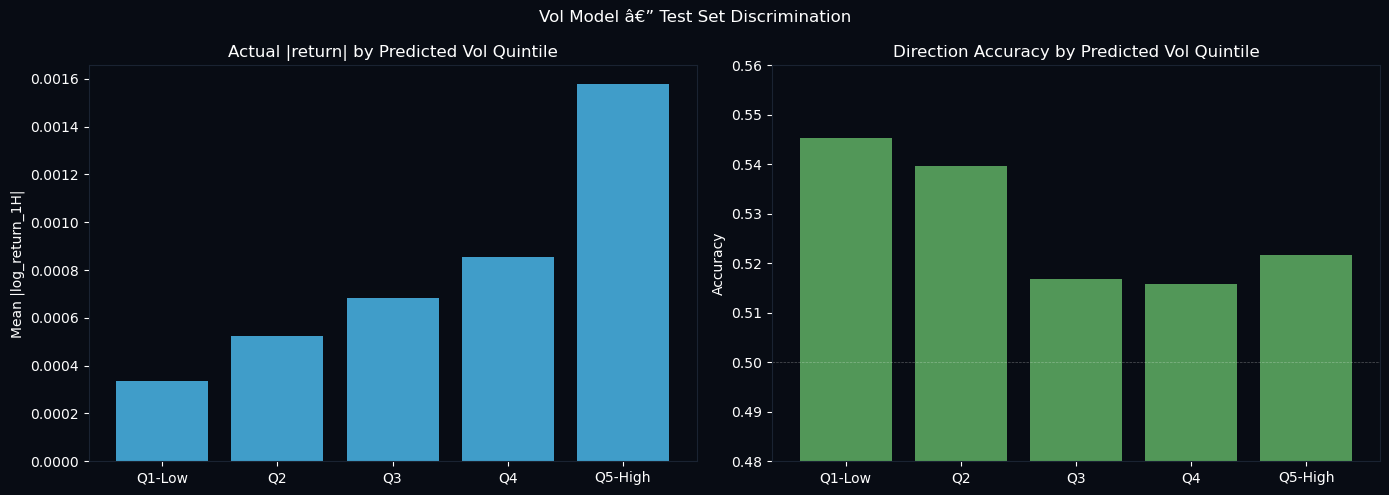

In [2]:
print('TEST 1 â€” Vol Model Discrimination on UNSEEN test set')
print('=' * 65)

# Quintile analysis
pred_bins = pd.qcut(results['pred_vol'], 5, labels=['Q1-Low', 'Q2', 'Q3', 'Q4', 'Q5-High'])
results['vol_quintile'] = pred_bins

print(f'\n{"Quintile":<12} {"Pred Vol":<14} {"Actual |ret|":<14} {"Dir Acc":<10} {"Avg PnL":<12} {"N"}')
print('-' * 68)

for q in ['Q1-Low', 'Q2', 'Q3', 'Q4', 'Q5-High']:
    subset = results[results['vol_quintile'] == q]
    print(f'{q:<12} {subset["pred_vol"].mean():<14.6f} {subset["actual_return"].abs().mean():<14.6f} '
          f'{subset["correct"].mean():<10.1%} {subset["pnl"].mean():<12.6f} {len(subset):,}')

ratio = results[results['vol_quintile'] == 'Q5-High']['actual_return'].abs().mean() / \
        results[results['vol_quintile'] == 'Q1-Low']['actual_return'].abs().mean()
print(f'\nQ5/Q1 actual vol ratio: {ratio:.2f}x')
print('(Higher = better vol discrimination on unseen data)')

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(DARK)

for ax in [ax1, ax2]:
    ax.set_facecolor(DARK)
    ax.tick_params(colors='white')
    for spine in ax.spines.values(): spine.set_edgecolor('#1a2332')

# Actual vol by predicted quintile
vol_means = results.groupby('vol_quintile')['actual_return'].apply(lambda x: x.abs().mean())
ax1.bar(vol_means.index, vol_means.values, color=BLUE, alpha=0.8)
ax1.set_title('Actual |return| by Predicted Vol Quintile', color='white')
ax1.set_ylabel('Mean |log_return_1H|', color='white')

# Direction accuracy by vol quintile
acc_means = results.groupby('vol_quintile')['correct'].mean()
ax2.bar(acc_means.index, acc_means.values, color=GREEN, alpha=0.8)
ax2.axhline(0.5, color='white', linewidth=0.5, linestyle='--', alpha=0.3)
ax2.set_title('Direction Accuracy by Predicted Vol Quintile', color='white')
ax2.set_ylabel('Accuracy', color='white')
ax2.set_ylim(0.48, 0.56)

plt.suptitle('Vol Model â€” Test Set Discrimination', color='white', fontsize=12)
plt.tight_layout()
plt.show()

---
## TEST 2 â€” Direction Accuracy by Vol Filter Threshold

In [3]:
print('TEST 2 â€” Direction Accuracy by Vol Filter (training thresholds)')
print('=' * 80)

vol_thresholds = {
    'All hours (no filter)': 0,
    'Top 75%': vol_pct[25],
    'Top 50% (median)': vol_pct[50],
    'Top 33%': vol_pct[67],
    'Top 20%': vol_pct[80],
    'Top 10%': vol_pct[90],
}

print(f'\n{"Filter":<25} {"Trades":>8} {"Accuracy":>10} {"Avg PnL":>12} {"Total PnL":>12} '
      f'{"Sharpe":>8} {"Max DD":>10} {"Win Rate":>10}')
print('-' * 100)

eval_rows = []
for name, thresh in vol_thresholds.items():
    mask = results['pred_vol'] > thresh
    if mask.sum() == 0:
        continue
    s = results[mask]
    pnl = s['pnl']
    cum_pnl = pnl.cumsum()
    running_max = cum_pnl.cummax()
    drawdown = cum_pnl - running_max
    max_dd = drawdown.min()
    sharpe = (pnl.mean() / pnl.std()) * np.sqrt(252 * 24) if pnl.std() > 0 else 0
    win_rate = (pnl > 0).mean()
    
    print(f'{name:<25} {mask.sum():>8,} {s["correct"].mean():>9.1%} {pnl.mean():>12.6f} '
          f'{pnl.sum():>12.4f} {sharpe:>8.2f} {max_dd:>10.4f} {win_rate:>9.1%}')
    eval_rows.append({'filter': name, 'trades': mask.sum(), 'accuracy': s['correct'].mean(),
                      'sharpe': sharpe, 'total_pnl': pnl.sum(), 'max_dd': max_dd})

# Also test with confidence filter on top of vol filter
print(f'\n\nWith additional direction confidence filter (>= 55%):')
print(f'{"Filter":<25} {"Trades":>8} {"Accuracy":>10} {"Avg PnL":>12} {"Total PnL":>12} {"Sharpe":>8}')
print('-' * 80)

for name, thresh in vol_thresholds.items():
    mask = (results['pred_vol'] > thresh) & (results['confidence'] >= 0.55)
    if mask.sum() < 50:
        continue
    s = results[mask]
    pnl = s['pnl']
    sharpe = (pnl.mean() / pnl.std()) * np.sqrt(252 * 24) if pnl.std() > 0 else 0
    print(f'{name:<25} {mask.sum():>8,} {s["correct"].mean():>9.1%} {pnl.mean():>12.6f} '
          f'{pnl.sum():>12.4f} {sharpe:>8.2f}')

TEST 2 â€” Direction Accuracy by Vol Filter (training thresholds)

Filter                      Trades   Accuracy      Avg PnL    Total PnL   Sharpe     Max DD   Win Rate
----------------------------------------------------------------------------------------------------
All hours (no filter)       62,531     52.8%     0.000109       6.8077     2.86    -0.1856     52.8%
Top 75%                     47,378     52.2%     0.000130       6.1597     2.99    -0.1852     52.2%
Top 50% (median)            30,334     51.8%     0.000172       5.2084     3.19    -0.2012     51.8%
Top 33%                     18,196     52.0%     0.000257       4.6785     3.76    -0.2185     52.0%
Top 20%                      9,930     52.3%     0.000451       4.4750     4.95    -0.2155     52.3%
Top 10%                      4,258     52.9%     0.000869       3.7008     6.82    -0.1523     52.9%


With additional direction confidence filter (>= 55%):
Filter                      Trades   Accuracy      Avg PnL    Total

---
## TEST 3 â€” Per-Pair Breakdown

TEST 3 â€” Per-Pair Breakdown on UNSEEN test set

All hours (threshold=0.000000):
  Pair         Trades   Accuracy      Avg PnL    Total PnL   Sharpe   Win Rate
  ---------------------------------------------------------------------------
  EURUSD        8,928     52.2%     0.000028       0.2491     2.07     52.2%
  GBPUSD        8,945     52.0%     0.000035       0.3136     1.83     52.0%
  USDJPY        8,955     51.7%     0.000026       0.2338     1.48     51.7%
  USDCHF        8,950     53.9%     0.000072       0.6479     4.96     53.9%
  AUDUSD        8,845     53.0%     0.000098       0.8655     3.98     53.0%
  USDCAD        8,955     53.4%     0.000241       2.1557     3.39     53.4%
  NZDUSD        8,953     53.2%     0.000262       2.3421     4.50     53.2%

Top 50% vol (threshold=0.000748):
  Pair         Trades   Accuracy      Avg PnL    Total PnL   Sharpe   Win Rate
  ---------------------------------------------------------------------------
  EURUSD        3,032     50.7

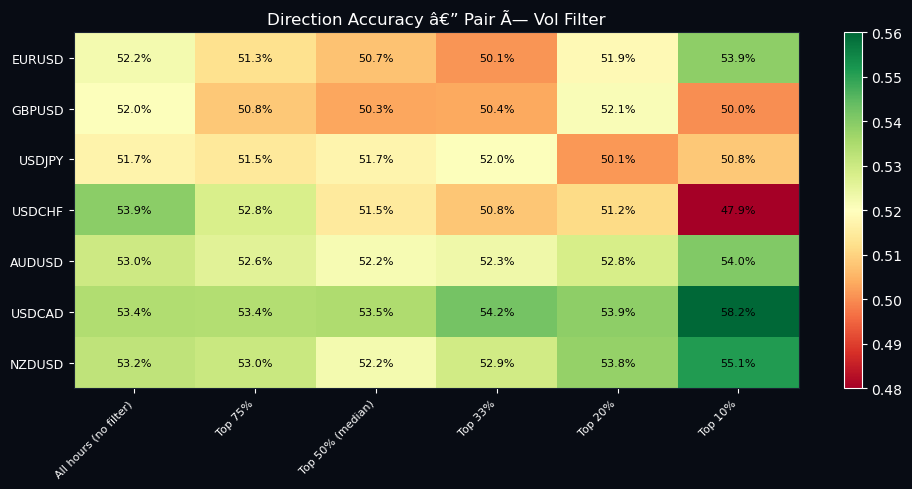

In [4]:
print('TEST 3 â€” Per-Pair Breakdown on UNSEEN test set')
print('=' * 90)

for filter_name, thresh in [('All hours', 0), ('Top 50% vol', vol_pct[50]), ('Top 20% vol', vol_pct[80])]:
    filtered = results[results['pred_vol'] > thresh]
    print(f'\n{filter_name} (threshold={thresh:.6f}):')
    print(f'  {"Pair":<10} {"Trades":>8} {"Accuracy":>10} {"Avg PnL":>12} {"Total PnL":>12} '
          f'{"Sharpe":>8} {"Win Rate":>10}')
    print(f'  {"-" * 75}')
    
    for pair in PAIRS:
        p = filtered[filtered['pair'] == pair]
        if len(p) < 50:
            continue
        pnl = p['pnl']
        sharpe = (pnl.mean() / pnl.std()) * np.sqrt(252 * 24) if pnl.std() > 0 else 0
        win_rate = (pnl > 0).mean()
        print(f'  {pair:<10} {len(p):>8,} {p["correct"].mean():>9.1%} {pnl.mean():>12.6f} '
              f'{pnl.sum():>12.4f} {sharpe:>8.2f} {win_rate:>9.1%}')

# Pair heatmap
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(DARK)
ax.set_facecolor(DARK)

pair_data = []
for pair in PAIRS:
    row = []
    for _, thresh in vol_thresholds.items():
        p = results[(results['pair'] == pair) & (results['pred_vol'] > thresh)]
        row.append(p['correct'].mean() if len(p) > 50 else np.nan)
    pair_data.append(row)

hm = np.array(pair_data)
im = ax.imshow(hm, cmap='RdYlGn', vmin=0.48, vmax=0.56, aspect='auto')
ax.set_xticks(range(len(vol_thresholds)))
ax.set_xticklabels(vol_thresholds.keys(), rotation=45, fontsize=8, color='white', ha='right')
ax.set_yticks(range(len(PAIRS)))
ax.set_yticklabels(PAIRS, fontsize=9, color='white')
for i in range(hm.shape[0]):
    for j in range(hm.shape[1]):
        if not np.isnan(hm[i, j]):
            ax.text(j, i, f'{hm[i,j]:.1%}', ha='center', va='center', fontsize=8, color='black')
plt.colorbar(im, ax=ax)
ax.set_title('Direction Accuracy â€” Pair Ã— Vol Filter', color='white')
for spine in ax.spines.values(): spine.set_edgecolor('#1a2332')
ax.tick_params(colors='white')
plt.tight_layout()
plt.show()

---
## TEST 4 â€” Rolling Accuracy (Detect Regime Decay)

TEST 4 â€” Rolling Accuracy on test set
All hours: mean=52.8%, first half=52.8%, second half=52.7%, decay=-0.1%
Top 50% vol: mean=51.8%, first half=52.1%, second half=51.4%, decay=-0.7%
Top 20% vol: mean=52.3%, first half=53.4%, second half=51.2%, decay=-2.2%


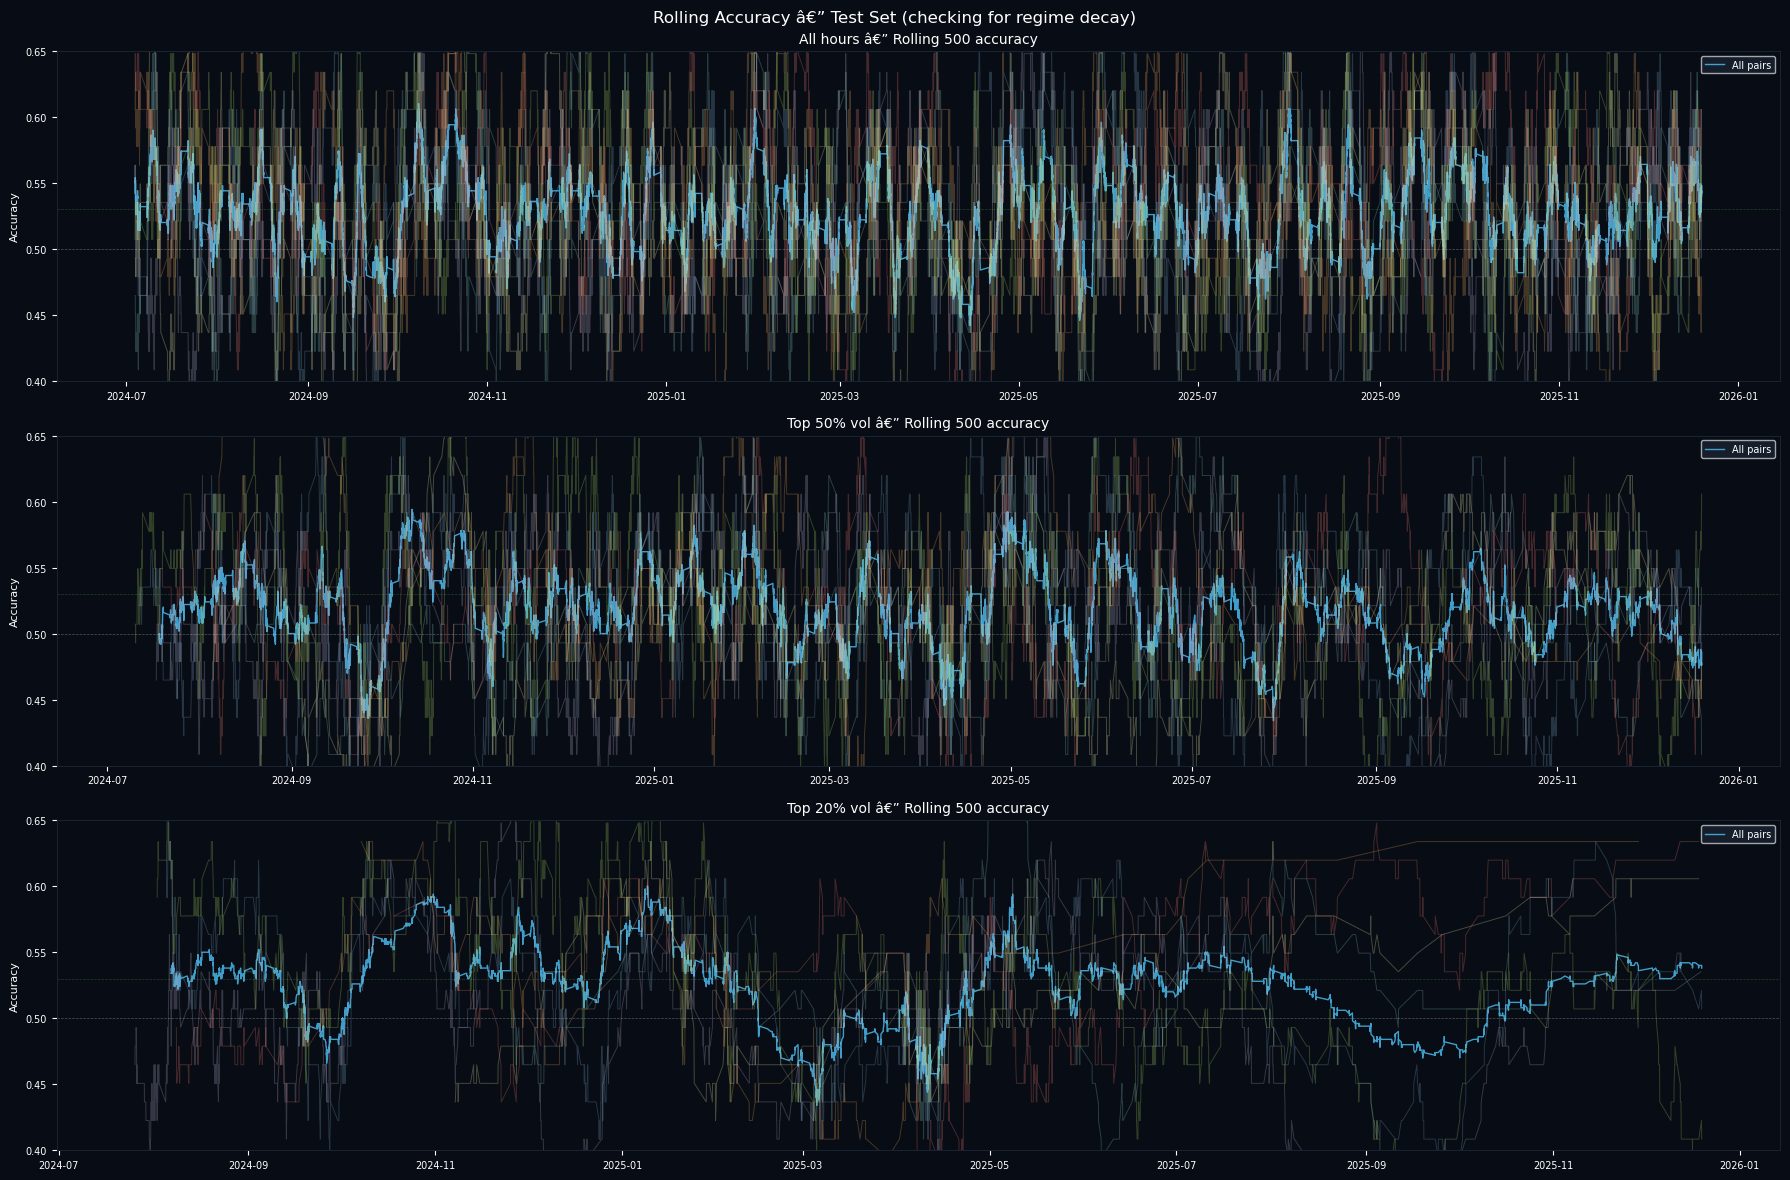

In [5]:
print('TEST 4 â€” Rolling Accuracy on test set')
print('=' * 60)

fig, axes = plt.subplots(3, 1, figsize=(18, 12))
fig.patch.set_facecolor(DARK)

window = 500  # ~3 weeks of hourly data across 7 pairs

for idx, (filter_name, thresh) in enumerate([('All hours', 0), ('Top 50% vol', vol_pct[50]), ('Top 20% vol', vol_pct[80])]):
    ax = axes[idx]
    ax.set_facecolor(DARK)
    
    filtered = results[results['pred_vol'] > thresh]
    
    # Overall rolling accuracy
    rolling_acc = filtered['correct'].astype(float).rolling(window).mean()
    ax.plot(rolling_acc.index, rolling_acc, color=BLUE, linewidth=1, alpha=0.8, label='All pairs')
    
    # Per-pair rolling
    for pair in PAIRS:
        p = filtered[filtered['pair'] == pair]
        if len(p) > window:
            r = p['correct'].astype(float).rolling(window // 7).mean()
            ax.plot(r.index, r, alpha=0.25, linewidth=0.7)
    
    ax.axhline(0.50, color='white', linewidth=0.5, linestyle='--', alpha=0.3)
    ax.axhline(0.53, color=GREEN, linewidth=0.5, linestyle='--', alpha=0.3)
    ax.set_ylim(0.40, 0.65)
    ax.set_title(f'{filter_name} â€” Rolling {window} accuracy', color='white', fontsize=10)
    ax.tick_params(colors='white', labelsize=7)
    ax.set_ylabel('Accuracy', color='white', fontsize=8)
    ax.legend(facecolor='#1a2332', labelcolor='white', fontsize=7)
    for spine in ax.spines.values(): spine.set_edgecolor('#1a2332')

    # Print stats
    mean_acc = filtered['correct'].mean()
    first_half = filtered.iloc[:len(filtered)//2]['correct'].mean()
    second_half = filtered.iloc[len(filtered)//2:]['correct'].mean()
    print(f'{filter_name}: mean={mean_acc:.1%}, first half={first_half:.1%}, second half={second_half:.1%}, '
          f'decay={second_half - first_half:+.1%}')

plt.suptitle('Rolling Accuracy â€” Test Set (checking for regime decay)', color='white', fontsize=12)
plt.tight_layout()
plt.show()

---
## TEST 5 â€” PnL Simulation: Equity Curves, Drawdowns, Streaks

TEST 5 â€” PnL Simulation


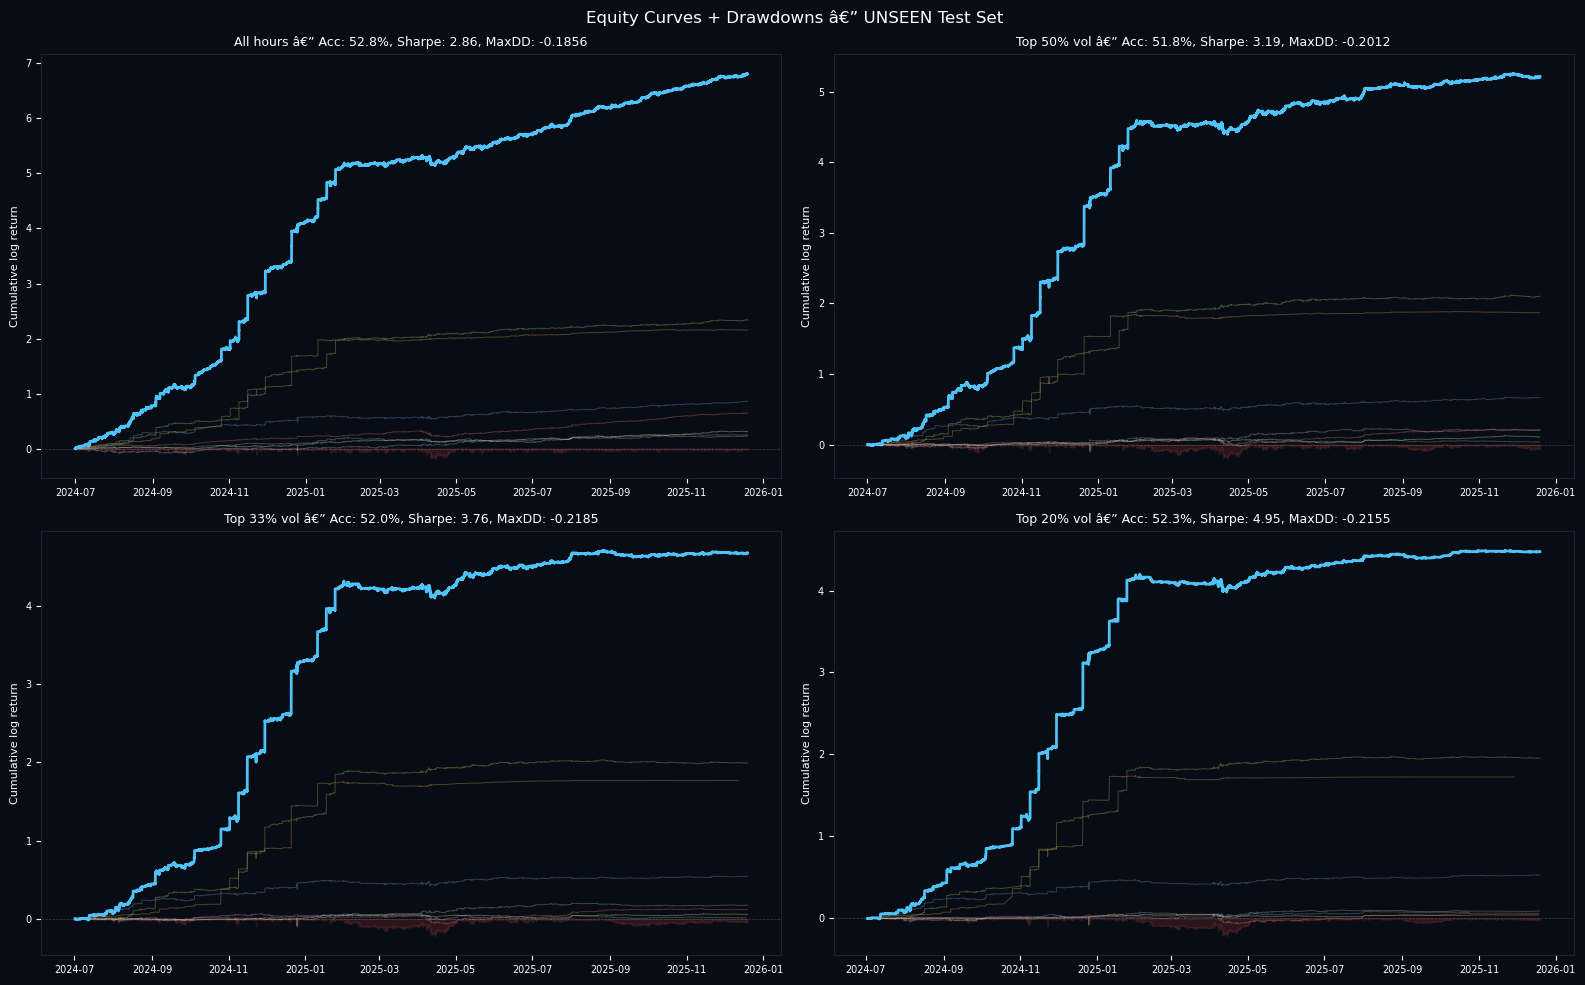


Win/Loss streak analysis (Top 50% vol):
  Longest win streak:  17
  Longest loss streak: 20
  Avg win streak:      2.3
  Avg loss streak:     2.1


In [6]:
print('TEST 5 â€” PnL Simulation')
print('=' * 60)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.patch.set_facecolor(DARK)

strategies = {
    'All hours': results,
    'Top 50% vol': results[results['pred_vol'] > vol_pct[50]],
    'Top 33% vol': results[results['pred_vol'] > vol_pct[67]],
    'Top 20% vol': results[results['pred_vol'] > vol_pct[80]],
}

for ax, (name, subset) in zip(axes.flatten(), strategies.items()):
    ax.set_facecolor(DARK)
    
    cum_pnl = subset['pnl'].cumsum()
    running_max = cum_pnl.cummax()
    drawdown = cum_pnl - running_max
    
    # Per-pair equity
    for pair in PAIRS:
        p = subset[subset['pair'] == pair]
        ax.plot(p['pnl'].cumsum().index, p['pnl'].cumsum().values, alpha=0.3, linewidth=0.7)
    
    # Aggregate
    ax.plot(cum_pnl.index, cum_pnl.values, color=BLUE, linewidth=2)
    ax.fill_between(drawdown.index, 0, drawdown.values, color=RED, alpha=0.15)
    ax.axhline(0, color='white', linewidth=0.5, linestyle='--', alpha=0.2)
    
    acc = subset['correct'].mean()
    sharpe = (subset['pnl'].mean() / subset['pnl'].std()) * np.sqrt(252 * 24) if subset['pnl'].std() > 0 else 0
    max_dd = drawdown.min()
    
    ax.set_title(f'{name} â€” Acc: {acc:.1%}, Sharpe: {sharpe:.2f}, MaxDD: {max_dd:.4f}', color='white', fontsize=9)
    ax.tick_params(colors='white', labelsize=7)
    ax.set_ylabel('Cumulative log return', color='white', fontsize=8)
    for spine in ax.spines.values(): spine.set_edgecolor('#1a2332')

plt.suptitle('Equity Curves + Drawdowns â€” UNSEEN Test Set', color='white', fontsize=12)
plt.tight_layout()
plt.show()

# Win/loss streaks
print('\nWin/Loss streak analysis (Top 50% vol):')
filtered = results[results['pred_vol'] > vol_pct[50]]
wins = filtered['pnl'] > 0
streaks = wins.ne(wins.shift()).cumsum()
win_streaks = wins.groupby(streaks).apply(lambda x: len(x) if x.iloc[0] else 0)
loss_streaks = wins.groupby(streaks).apply(lambda x: len(x) if not x.iloc[0] else 0)
print(f'  Longest win streak:  {win_streaks.max()}')
print(f'  Longest loss streak: {loss_streaks.max()}')
print(f'  Avg win streak:      {win_streaks[win_streaks > 0].mean():.1f}')
print(f'  Avg loss streak:     {loss_streaks[loss_streaks > 0].mean():.1f}')

---
## TEST 6 â€” Confidence Ã— Vol Filter Heatmap

TEST 6 â€” Accuracy Ã— Vol Filter Ã— Direction Confidence


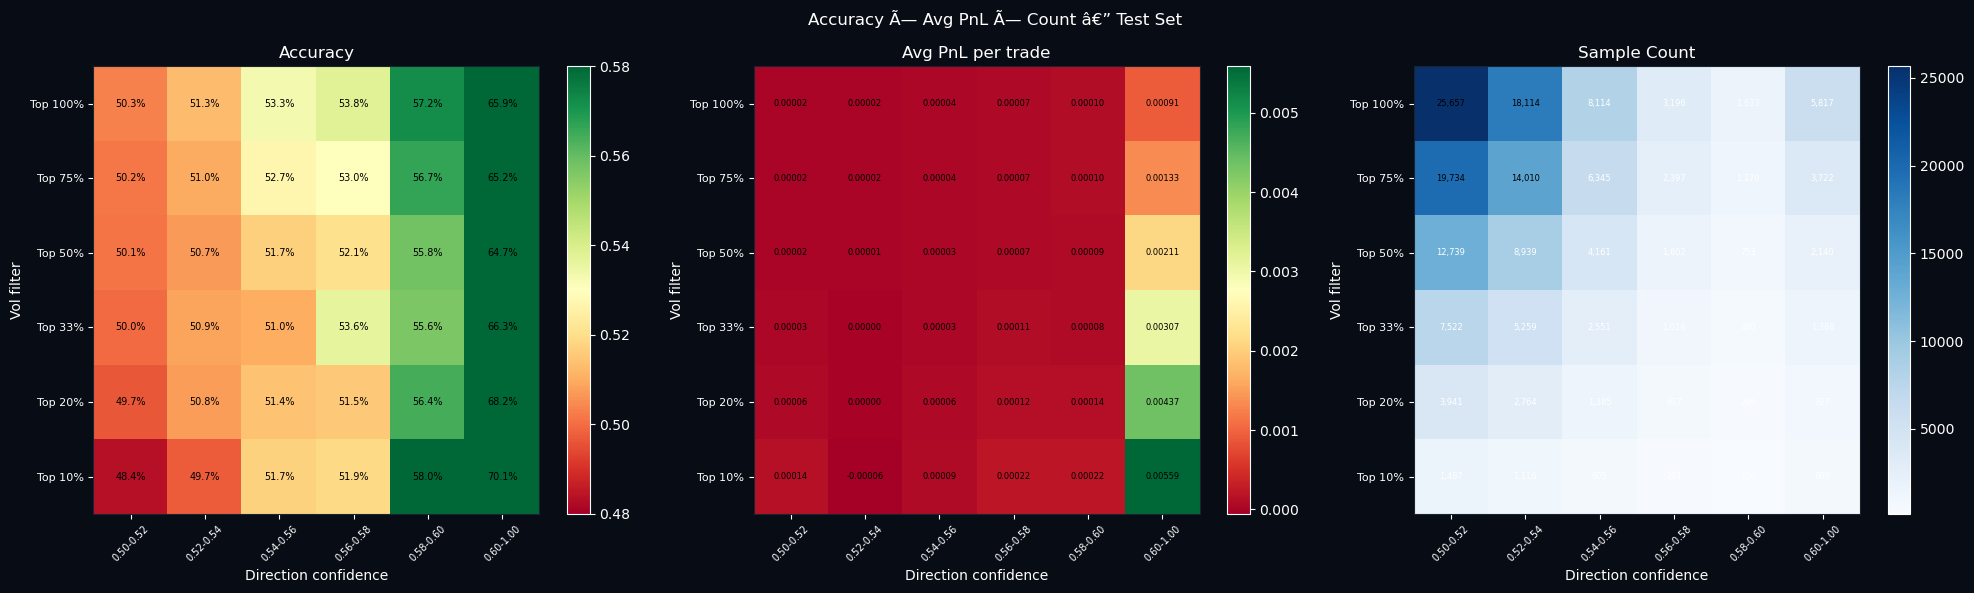

In [7]:
print('TEST 6 â€” Accuracy Ã— Vol Filter Ã— Direction Confidence')
print('=' * 60)

vol_thresh_map = {0: 0, 25: vol_pct[25], 50: vol_pct[50], 67: vol_pct[67], 80: vol_pct[80], 90: vol_pct[90]}
vol_pcts_list = [0, 25, 50, 67, 80, 90]
conf_edges = [0.50, 0.52, 0.54, 0.56, 0.58, 0.60, 1.0]

heatmap_acc = np.zeros((len(vol_pcts_list), len(conf_edges) - 1))
heatmap_pnl = np.zeros_like(heatmap_acc)
counts = np.zeros_like(heatmap_acc)

for i, vp in enumerate(vol_pcts_list):
    vthresh = vol_thresh_map[vp]
    vmask = results['pred_vol'] > vthresh
    for j in range(len(conf_edges) - 1):
        lo, hi = conf_edges[j], conf_edges[j + 1]
        cmask = (results['confidence'] >= lo) & (results['confidence'] < hi)
        subset = results[vmask & cmask]
        if len(subset) > 50:
            heatmap_acc[i, j] = subset['correct'].mean()
            heatmap_pnl[i, j] = subset['pnl'].mean()
            counts[i, j] = len(subset)
        else:
            heatmap_acc[i, j] = np.nan
            heatmap_pnl[i, j] = np.nan

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))
fig.patch.set_facecolor(DARK)

conf_labels = [f'{conf_edges[j]:.2f}-{conf_edges[j+1]:.2f}' for j in range(len(conf_edges)-1)]
vol_labels = [f'Top {100-vp}%' for vp in vol_pcts_list]

for ax in [ax1, ax2, ax3]:
    ax.set_facecolor(DARK)
    ax.tick_params(colors='white')
    for spine in ax.spines.values(): spine.set_edgecolor('#1a2332')

# Accuracy
im1 = ax1.imshow(heatmap_acc, cmap='RdYlGn', vmin=0.48, vmax=0.58, aspect='auto')
ax1.set_xticks(range(len(conf_labels))); ax1.set_xticklabels(conf_labels, rotation=45, fontsize=7, color='white')
ax1.set_yticks(range(len(vol_labels))); ax1.set_yticklabels(vol_labels, fontsize=8, color='white')
ax1.set_xlabel('Direction confidence', color='white'); ax1.set_ylabel('Vol filter', color='white')
ax1.set_title('Accuracy', color='white')
for i in range(heatmap_acc.shape[0]):
    for j in range(heatmap_acc.shape[1]):
        if not np.isnan(heatmap_acc[i,j]):
            ax1.text(j, i, f'{heatmap_acc[i,j]:.1%}', ha='center', va='center', fontsize=7, color='black')
plt.colorbar(im1, ax=ax1)

# Avg PnL
im2 = ax2.imshow(heatmap_pnl, cmap='RdYlGn', aspect='auto')
ax2.set_xticks(range(len(conf_labels))); ax2.set_xticklabels(conf_labels, rotation=45, fontsize=7, color='white')
ax2.set_yticks(range(len(vol_labels))); ax2.set_yticklabels(vol_labels, fontsize=8, color='white')
ax2.set_xlabel('Direction confidence', color='white'); ax2.set_ylabel('Vol filter', color='white')
ax2.set_title('Avg PnL per trade', color='white')
for i in range(heatmap_pnl.shape[0]):
    for j in range(heatmap_pnl.shape[1]):
        if not np.isnan(heatmap_pnl[i,j]):
            ax2.text(j, i, f'{heatmap_pnl[i,j]:.5f}', ha='center', va='center', fontsize=6, color='black')
plt.colorbar(im2, ax=ax2)

# Count
im3 = ax3.imshow(counts, cmap='Blues', aspect='auto')
ax3.set_xticks(range(len(conf_labels))); ax3.set_xticklabels(conf_labels, rotation=45, fontsize=7, color='white')
ax3.set_yticks(range(len(vol_labels))); ax3.set_yticklabels(vol_labels, fontsize=8, color='white')
ax3.set_xlabel('Direction confidence', color='white'); ax3.set_ylabel('Vol filter', color='white')
ax3.set_title('Sample Count', color='white')
for i in range(counts.shape[0]):
    for j in range(counts.shape[1]):
        if counts[i,j] > 0:
            ax3.text(j, i, f'{int(counts[i,j]):,}', ha='center', va='center', fontsize=6,
                     color='white' if counts[i,j] < counts.max()/2 else 'black')
plt.colorbar(im3, ax=ax3)

plt.suptitle('Accuracy Ã— Avg PnL Ã— Count â€” Test Set', color='white', fontsize=12)
plt.tight_layout()
plt.show()

---
## TEST 7 â€” Momentum Baseline Comparison

In [8]:
print('TEST 7 â€” Momentum Baseline vs Two-Stage Model')
print('=' * 65)

# Simple momentum features for baseline
momentum_cols = [c for c in feature_cols if 'log_ret' in c and ('1H' in c or '5m' in c)]
momentum_cols += [c for c in feature_cols if 'rsi_14' in c or 'macd_hist' in c]
momentum_cols = momentum_cols[:15]  # cap at 15 features

print(f'Baseline features ({len(momentum_cols)}): {momentum_cols[:5]}...\n')

print(f'{"Pair":<10} {"LR Baseline":>12} {"Model (all)":>12} {"Alpha":>8} '
      f'{"Model (50%)":>12} {"Alpha":>8}')
print('-' * 70)

for pair in PAIRS:
    df_pair_train = df_train[df_train['pair'] == pair]
    df_pair_test = df_test[df_test['pair'] == pair]
    
    y_tr = (df_pair_train[TARGET_COL] > 0).astype(int).values
    y_te = (df_pair_test[TARGET_COL] > 0).astype(int).values
    
    X_tr = df_pair_train[momentum_cols].ffill().fillna(0).values
    X_te = df_pair_test[momentum_cols].ffill().fillna(0).values
    
    valid_tr = ~np.isnan(y_tr) & ~np.isnan(X_tr).any(axis=1)
    valid_te = ~np.isnan(y_te) & ~np.isnan(X_te).any(axis=1)
    
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr[valid_tr])
    X_te_s = scaler.transform(X_te[valid_te])
    
    lr = LogisticRegression(max_iter=1000, C=0.1)
    lr.fit(X_tr_s, y_tr[valid_tr])
    lr_acc = (lr.predict(X_te_s) == y_te[valid_te]).mean()
    
    # Our model
    pair_results = results[results['pair'] == pair]
    model_acc_all = pair_results['correct'].mean()
    pair_filtered = pair_results[pair_results['pred_vol'] > vol_pct[50]]
    model_acc_50 = pair_filtered['correct'].mean() if len(pair_filtered) > 50 else float('nan')
    
    print(f'{pair:<10} {lr_acc:>11.1%} {model_acc_all:>11.1%} {model_acc_all - lr_acc:>+7.1%} '
          f'{model_acc_50:>11.1%} {model_acc_50 - lr_acc:>+7.1%}')

TEST 7 â€” Momentum Baseline vs Two-Stage Model
Baseline features (15): ['log_ret_1_1H', 'log_ret_3_1H', 'log_ret_6_1H', 'log_ret_12_1H', 'log_ret_24_1H']...

Pair        LR Baseline  Model (all)    Alpha  Model (50%)    Alpha
----------------------------------------------------------------------
EURUSD           52.2%       52.2%   +0.0%       50.7%   -1.5%
GBPUSD           51.5%       52.0%   +0.6%       50.3%   -1.1%
USDJPY           50.5%       51.7%   +1.2%       51.7%   +1.2%
USDCHF           52.5%       53.9%   +1.4%       51.5%   -1.0%
AUDUSD           52.5%       53.0%   +0.5%       52.2%   -0.3%
USDCAD           52.9%       53.4%   +0.5%       53.5%   +0.6%
NZDUSD           51.7%       53.2%   +1.5%       52.2%   +0.6%


---
## TEST 8 â€” Permutation Test

In [9]:
print('TEST 8 â€” Permutation Test (200 shuffles)')
print('=' * 60)

N_PERMS = 200

for filter_name, thresh in [('All hours', 0), ('Top 50% vol', vol_pct[50]), ('Top 20% vol', vol_pct[80])]:
    filtered = results[results['pred_vol'] > thresh]
    real_acc = filtered['correct'].mean()
    real_pnl = filtered['pnl'].sum()
    
    perm_accs = []
    perm_pnls = []
    for _ in range(N_PERMS):
        shuffled_returns = np.random.permutation(filtered['actual_return'].values)
        shuffled_dir = np.where(shuffled_returns > 0, 1, -1)
        perm_correct = (filtered['pred_dir'].values == shuffled_dir).mean()
        perm_pnl = (filtered['pred_dir'].values * shuffled_returns).sum()
        perm_accs.append(perm_correct)
        perm_pnls.append(perm_pnl)
    
    perm_mean = np.mean(perm_accs)
    perm_std = np.std(perm_accs)
    z_score = (real_acc - perm_mean) / perm_std if perm_std > 0 else 0
    p_value = (np.array(perm_accs) >= real_acc).mean()
    
    pnl_z = (real_pnl - np.mean(perm_pnls)) / np.std(perm_pnls) if np.std(perm_pnls) > 0 else 0
    
    verdict = 'GENUINE' if p_value < 0.01 else ('MARGINAL' if p_value < 0.05 else 'NOT SIGNIFICANT')
    
    print(f'\n{filter_name} ({len(filtered):,} trades):')
    print(f'  Real accuracy:     {real_acc:.4f}')
    print(f'  Permuted mean/std: {perm_mean:.4f} Â± {perm_std:.4f}')
    print(f'  Z-score:           {z_score:.2f}  (p={p_value:.4f})')
    print(f'  Real PnL:          {real_pnl:.4f}  (Z={pnl_z:.2f})')
    print(f'  Verdict:           {verdict}')

TEST 8 â€” Permutation Test (200 shuffles)

All hours (62,531 trades):
  Real accuracy:     0.5279
  Permuted mean/std: 0.5002 Â± 0.0019
  Z-score:           14.52  (p=0.0000)
  Real PnL:          6.8077  (Z=9.21)
  Verdict:           GENUINE

Top 50% vol (30,334 trades):
  Real accuracy:     0.5179
  Permuted mean/std: 0.4997 Â± 0.0029
  Z-score:           6.22  (p=0.0000)
  Real PnL:          5.2084  (Z=6.80)
  Verdict:           GENUINE

Top 20% vol (9,930 trades):
  Real accuracy:     0.5226
  Permuted mean/std: 0.4994 Â± 0.0050
  Z-score:           4.60  (p=0.0000)
  Real PnL:          4.4750  (Z=6.50)
  Verdict:           GENUINE


---
## TEST 9 â€” Trade Frequency & Hour-of-Day Analysis

TEST 9 â€” Trade Frequency & Hour-of-Day Analysis
All hours (no filter)    :   62,531 trades, ~162.8/day across all pairs
Top 75%                  :   47,378 trades, ~123.4/day across all pairs
Top 50% (median)         :   30,334 trades, ~79.0/day across all pairs
Top 33%                  :   18,196 trades, ~47.4/day across all pairs
Top 20%                  :    9,930 trades, ~25.9/day across all pairs
Top 10%                  :    4,258 trades, ~11.1/day across all pairs


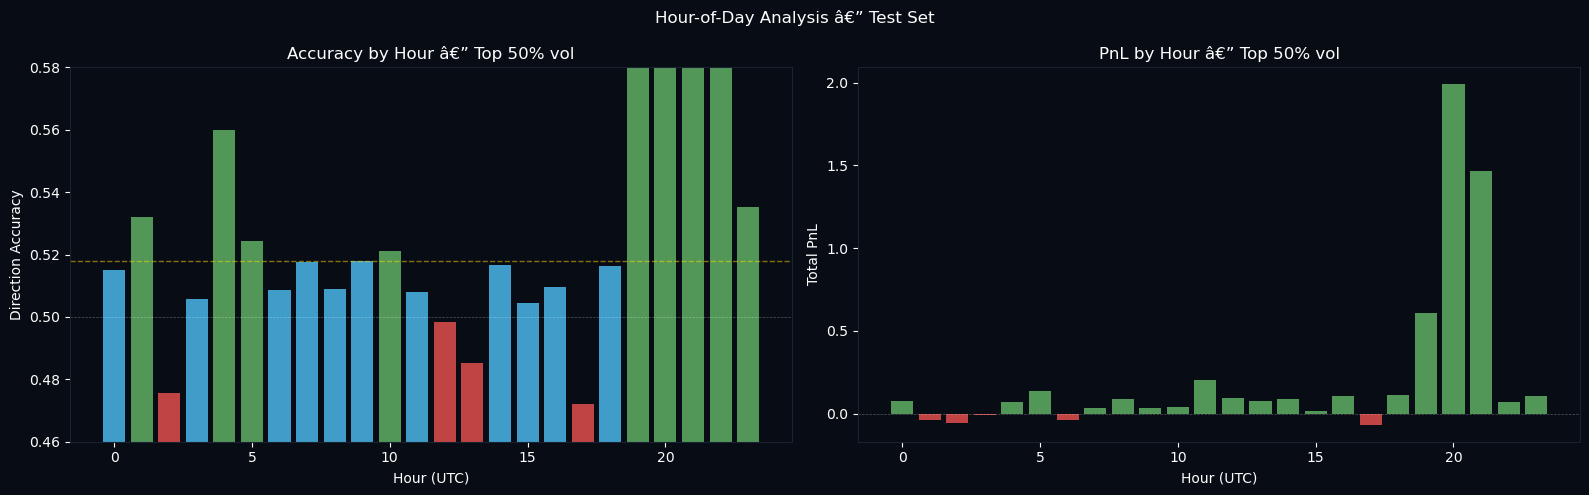


Accuracy by day of week (Top 50% vol):
  Mon: 51.4% (4,757 trades, PnL=0.1570)
  Tue: 52.1% (6,096 trades, PnL=0.5036)
  Wed: 51.3% (6,361 trades, PnL=0.3041)
  Thu: 52.1% (6,418 trades, PnL=0.3189)
  Fri: 51.9% (6,702 trades, PnL=3.9249)


In [10]:
print('TEST 9 â€” Trade Frequency & Hour-of-Day Analysis')
print('=' * 60)

results['hour'] = results.index.hour
results['day_of_week'] = results.index.dayofweek

# Trade frequency by vol filter
for name, thresh in vol_thresholds.items():
    n = (results['pred_vol'] > thresh).sum()
    hours_total = len(results) / 7  # per pair
    trades_per_day = n / (len(results.index.normalize().unique())) 
    print(f'{name:<25}: {n:>8,} trades, ~{trades_per_day:.1f}/day across all pairs')

# Accuracy by hour of day (Top 50% vol)
filtered = results[results['pred_vol'] > vol_pct[50]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor(DARK)

for ax in [ax1, ax2]:
    ax.set_facecolor(DARK)
    ax.tick_params(colors='white')
    for spine in ax.spines.values(): spine.set_edgecolor('#1a2332')

# Accuracy by hour
hour_acc = filtered.groupby('hour')['correct'].mean()
hour_count = filtered.groupby('hour').size()
colors_h = [GREEN if a > 0.52 else (RED if a < 0.50 else BLUE) for a in hour_acc.values]
ax1.bar(hour_acc.index, hour_acc.values, color=colors_h, alpha=0.8)
ax1.axhline(0.50, color='white', linewidth=0.5, linestyle='--', alpha=0.3)
ax1.axhline(filtered['correct'].mean(), color=GOLD, linewidth=1, linestyle='--', alpha=0.5)
ax1.set_xlabel('Hour (UTC)', color='white')
ax1.set_ylabel('Direction Accuracy', color='white')
ax1.set_title('Accuracy by Hour â€” Top 50% vol', color='white')
ax1.set_ylim(0.46, 0.58)

# PnL by hour
hour_pnl = filtered.groupby('hour')['pnl'].sum()
colors_p = [GREEN if p > 0 else RED for p in hour_pnl.values]
ax2.bar(hour_pnl.index, hour_pnl.values, color=colors_p, alpha=0.8)
ax2.axhline(0, color='white', linewidth=0.5, linestyle='--', alpha=0.3)
ax2.set_xlabel('Hour (UTC)', color='white')
ax2.set_ylabel('Total PnL', color='white')
ax2.set_title('PnL by Hour â€” Top 50% vol', color='white')

plt.suptitle('Hour-of-Day Analysis â€” Test Set', color='white', fontsize=12)
plt.tight_layout()
plt.show()

# Day of week
print('\nAccuracy by day of week (Top 50% vol):')
dow_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
for dow in range(7):
    d = filtered[filtered['day_of_week'] == dow]
    if len(d) > 50:
        print(f'  {dow_names[dow]}: {d["correct"].mean():.1%} ({len(d):,} trades, PnL={d["pnl"].sum():.4f})')

---
## SUMMARY

In [12]:
print('=' * 70)
print('EVALUATION SUMMARY — Two-Stage Vol + Direction Model')
print(f'Trained: 2009 to {TRAIN_END}')
print(f'Tested:  {results.index.min().date()} to {results.index.max().date()} (UNSEEN)')
print('=' * 70)

print(f'\nModels: {MODELS_DIR.resolve()}')
print('  Vol model:  predicts |log_return_1H|')
print('  Dir model:  predicts UP/DOWN (trained on high-vol rows)')

print('\n── Overall (no filter) ──')
print(f'  Accuracy:  {results["correct"].mean():.1%}')
print(f'  Total PnL: {results["pnl"].sum():.4f}')
sharpe_all = (results['pnl'].mean() / results['pnl'].std()) * np.sqrt(252 * 24)
print(f'  Sharpe:    {sharpe_all:.2f}')
print(f'  Trades:    {len(results):,}')

for name, thresh in [('Top 50% vol', vol_pct[50]), ('Top 20% vol', vol_pct[80]), ('Top 10% vol', vol_pct[90])]:
    f = results[results['pred_vol'] > thresh]
    pnl = f['pnl']
    sharpe = (pnl.mean() / pnl.std()) * np.sqrt(252 * 24) if pnl.std() > 0 else 0
    cum = pnl.cumsum()
    max_dd = (cum - cum.cummax()).min()
    print(f'\n── {name} ──')
    print(f'  Accuracy:  {f["correct"].mean():.1%}')
    print(f'  Total PnL: {pnl.sum():.4f}')
    print(f'  Sharpe:    {sharpe:.2f}')
    print(f'  Max DD:    {max_dd:.4f}')
    print(f'  Trades:    {len(f):,}')

print('\n── Best pairs (Top 50% vol) ──')
f50 = results[results['pred_vol'] > vol_pct[50]]
for pair in sorted(PAIRS, key=lambda p: f50[f50['pair']==p]['pnl'].sum(), reverse=True):
    p = f50[f50['pair'] == pair]
    print(f'  {pair}: {p["correct"].mean():.1%} acc, PnL={p["pnl"].sum():.4f}')


EVALUATION SUMMARY — Two-Stage Vol + Direction Model
Trained: 2009 to 2024-06-30
Tested:  2024-07-01 to 2025-12-19 (UNSEEN)

Models: C:\Users\noual\lumeny\backend\models_4
  Vol model:  predicts |log_return_1H|
  Dir model:  predicts UP/DOWN (trained on high-vol rows)

── Overall (no filter) ──
  Accuracy:  52.8%
  Total PnL: 6.8083
  Sharpe:    2.86
  Trades:    62,532

── Top 50% vol ──
  Accuracy:  51.8%
  Total PnL: 5.2084
  Sharpe:    3.19
  Max DD:    -0.2012
  Trades:    30,334

── Top 20% vol ──
  Accuracy:  52.3%
  Total PnL: 4.4750
  Sharpe:    4.95
  Max DD:    -0.2155
  Trades:    9,930

── Top 10% vol ──
  Accuracy:  52.9%
  Total PnL: 3.7008
  Sharpe:    6.82
  Max DD:    -0.1523
  Trades:    4,258

── Best pairs (Top 50% vol) ──
  NZDUSD: 52.2% acc, PnL=2.1034
  USDCAD: 53.5% acc, PnL=1.8712
  AUDUSD: 52.2% acc, PnL=0.6693
  USDJPY: 51.7% acc, PnL=0.2140
  USDCHF: 51.5% acc, PnL=0.2059
  GBPUSD: 50.3% acc, PnL=0.1100
  EURUSD: 50.7% acc, PnL=0.0346
